In [1]:
import numpy as np
import matplotlib.pyplot as plt
print('Setup complete!')

Setup complete!


In [2]:
# ============ Simulation Parameters ============
dt = 0.001 # Time step (1 ms)
T = 1.0 # Total simulation time (1 second)
time = np.arange(0, T, dt) # Time array
# ============ Neuron Parameters ============
V_rest = -70.0 # Resting potential (mV)
V_thresh = -55.0 # Spike threshold (mV)
V_reset = -75.0 # Reset potential after spike (mV)
tau = 0.020 # Membrane time constant (20 ms)
C = 1.0 # Membrane capacitance (normalized)
print(f'Simulation: {T}s with {len(time)} time steps')
print(f'Threshold: {V_thresh} mV, Rest: {V_rest} mV')

Simulation: 1.0s with 1000 time steps
Threshold: -55.0 mV, Rest: -70.0 mV


KNOWLEDGE CHECK
1. Why is V_reset (-75 mV) lower than V_rest (-70 mV)? What biological phenomenon does this
represent?
Setting V_reset = -75 mV (below the resting −70 mV) mimics a real biological effect called after-hyperpolarization. The neuron gets “extra tired” after firing, so its voltage drops lower than usual before recovering.

2. The time constant tau is 20 ms. In plain English, what does this control?
The membrane time constant tells you how quickly the neuron reacts to changes.

It’s like filling a leaky bucket — T tells you how quickly the water level responds when you turn the faucet on or off.

In [4]:
import numpy as np

# Simulation parameters
dt = 0.001
T = 1.0
time = np.arange(0, T, dt)

# Neuron parameters
V_rest = -70.0
V_thresh = -55.0
V_reset = -75.0
tau = 0.020
C = 1.0

# Input current
I_input = np.zeros(len(time))
I_input[200:800] = 15.0

# Storage arrays  ← THIS defines V
V = np.zeros(len(time))
V[0] = V_rest
spikes = []

In [6]:
# ============ Input Current ============
# Constant current injection (t = 200 ms to 800 ms)
I_input = np.zeros(len(time))
I_input[200:800] = 22.0   # 22 nA -> typically ~20–25 spikes with params below

# ============ LIF Scaling (important!) ============
# Add membrane resistance so current has the right voltage effect (classic LIF form)
R = 1.0  # mV per nA (think "how many mV you get per nA")

# ============ Storage Arrays ============
V = np.zeros(len(time))
V[0] = V_rest
spikes = []

# ============ Simulation Loop ============
for t in range(len(time) - 1):

    # TODO 1: Compute the voltage change using the LIF equation (Euler step)
    # tau * dV/dt = -(V - V_rest) + R*I
    dV = (dt / tau) * (-(V[t] - V_rest) + R * I_input[t])

    # TODO 2: Update the membrane potential
    V[t+1] = V[t] + dV

    # TODO 3: Threshold + reset
    if V[t+1] >= V_thresh:
        spikes.append(time[t+1])
        V[t+1] = V_reset

print(f'Neuron fired {len(spikes)} spikes')

Neuron fired 22 spikes


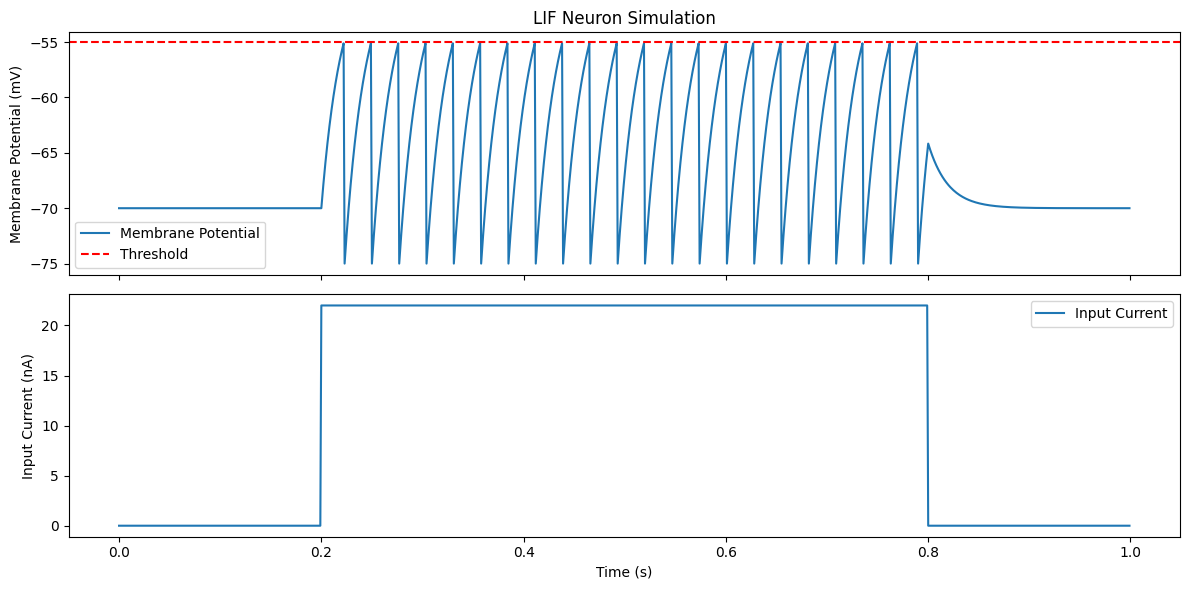

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# TODO 4: Plot the membrane potential on ax1
ax1.plot(time, V, label='Membrane Potential')
ax1.axhline(y=V_thresh, color='r', linestyle='--', label='Threshold')

ax1.set_ylabel('Membrane Potential (mV)')
ax1.set_title('LIF Neuron Simulation')
ax1.legend()

# TODO 5: Plot the input current on ax2
ax2.plot(time, I_input, label='Input Current')
ax2.legend()

ax2.set_ylabel('Input Current (nA)')
ax2.set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

KNOWLEDGE CHECK
1. Look at your membrane potential plot. What happens to V between spikes — does it go straight
up, or does it curve? Why?

When V is far from rest - strong push upward from the input current.

As V gets closer to its steady level - the leak grows and cancels more of the input.


2. What happens to V after the current turns off at t=800ms? Why does it behave this way?

Between spikes - V curves upward because leak slows the rise as voltage increases.

After 800 ms - V exponentially decays back to rest because only the leak term remains.

REFLECTION

Look at your membrane potential trace. In the booklet, you learned that biological neurons show
similar integrate-and-fire behavior. What aspects of your plot look “realistic” compared to what you
read about real neurons? What looks overly simplified?

Realistic:

- exponential charging/leak

- threshold firing

- refractory-like reset

- gradual integration of inputs


Simplified:

- no spike shape (instant reset)

- constant threshold

- noiseless input

- no ion channel dynamics

In [8]:
def rate_encode(values, num_steps=100):
    """
    Convert an array of values (0 to 1) into spike trains.
    Args:
        values: 1D numpy array with values between 0 and 1
        num_steps: number of time steps to simulate
    Returns:
        spikes: 2D array of shape (num_steps, len(values))
        where 1 = spike, 0 = no spike
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for t in range(num_steps):
        # Generate spikes probabilistically based on values
        spikes[t] = (np.random.rand(num_neurons) < values).astype(float)

    return spikes

In [10]:
# Test with 5 values of increasing intensity
test_values = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
test_spikes = rate_encode(test_values, num_steps=200)

# Count spikes per neuron
for i, v in enumerate(test_values):
    count = test_spikes[:, i].sum()
    print(f'Value {v:.1f} -> {count:.0f} spikes in 200 steps')

Value 0.1 -> 16 spikes in 200 steps
Value 0.3 -> 67 spikes in 200 steps
Value 0.5 -> 92 spikes in 200 steps
Value 0.7 -> 138 spikes in 200 steps
Value 0.9 -> 175 spikes in 200 steps


In [11]:
def temporal_encode(values, num_steps=100, threshold=0.05):
    """
    Convert values (0 to 1) into spike trains using time-to-first-spike.
    Higher values spike earlier.
    Args:
        values: 1D numpy array with values between 0 and 1
        num_steps: number of time steps
        threshold: minimum value to produce a spike
    Returns:
        spikes: 2D array (num_steps, len(values))
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for i in range(num_neurons):
        if values[i] > threshold:
            # Higher value → earlier spike
            spike_time = int((1 - values[i]) * (num_steps - 1))
            spikes[spike_time, i] = 1

    return spikes

KNOWLEDGE CHECK

1. In rate coding, what information is lost about the original signal? What is preserved?

Preserved
- The average intensity or strength of the signal.

- Higher input - higher spike frequency.

- Good for representing overall magnitude.

Lost

- Precise timing of individual spikes.

- Fast changes or exact temporal patterns.

- Two very different spike trains can have the same firing rate, so detailed timing information disappears.

2. In temporal coding, why might it be faster for a downstream neuron to make a decision compared
to rate coding?

In temporal coding, information is carried by when the first spike happens, not by counting many spikes.

A downstream neuron may only need one early spike to detect a strong signal.

Rate coding requires waiting to accumulate enough spikes to estimate firing frequency.

3. Can you think of a real-world example where timing matters more than frequency? (Hint: think
about sound localization.)

- A classic example is sound localization.

- Your brain compares tiny timing differences between when sound reaches each ear (on the order of microseconds).

- The exact spike timing in auditory neurons tells the brain where the sound came from.

- Frequency alone wouldn’t give direction, timing does.

In [14]:
# Create a test signal: 20 values from 0.05 to 1.0
signal = np.linspace(0.05, 1.0, 20)

# Encode with both methods
rate_spikes = rate_encode(signal, num_steps=200)
temp_spikes = temporal_encode(signal, num_steps=200)

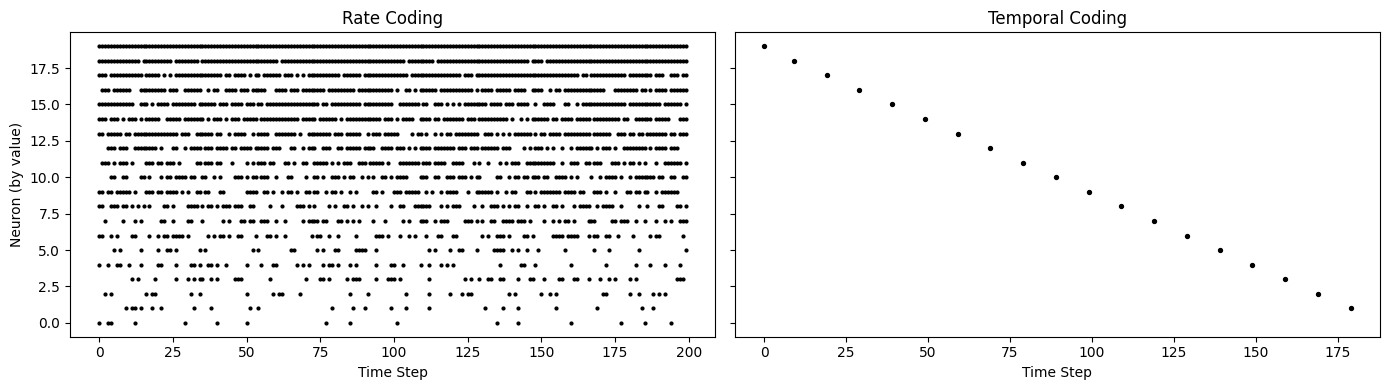

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

# --- Rate coding raster ---
times, neurons = np.where(rate_spikes == 1)
ax1.scatter(times, neurons, s=4, color='black')
ax1.set_title('Rate Coding')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Neuron (by value)')

# --- Temporal coding raster ---
times, neurons = np.where(temp_spikes == 1)
ax2.scatter(times, neurons, s=8, color='black')
ax2.set_title('Temporal Coding')
ax2.set_xlabel('Time Step')

plt.tight_layout()
plt.show()

REFLECTION

Compare your two raster plots. Which encoding would be better for a system that needs to react
quickly? Which would be better for a system that needs precise measurements? The brain uses both
strategies in different circuits — why do you think that is?

Temporal coding is better for rapid reactions because information is conveyed by early spike timing, allowing downstream neurons to respond quickly. Rate coding is better for precise measurements because averaging many spikes reduces noise and improves reliability.

The brain uses both because different tasks require different trade-offs between speed and accuracy.

In [16]:
# Network parameters
N = 5
T_net = 0.5
time_net = np.arange(0, T_net, dt)
steps = len(time_net)

# Weight matrix: weights[pre, post]
weights = np.zeros((N, N))
weights[0, 2] = 12.0
weights[1, 3] = 12.0
weights[2, 4] = 10.0
weights[3, 4] = 10.0

# External input (only to neurons 0 and 1)
I_ext = np.zeros((steps, N))
I_ext[100:400, 0] = 18.0
I_ext[150:350, 1] = 18.0

# Storage
V_net = np.full((steps, N), V_rest)
spike_log = [[] for _ in range(N)]

# LIF scaling (if you used this earlier)
R = 1.0  # mV per nA

# Track which neurons spiked on the previous time step (for synapses)
spiked_prev = np.zeros(N, dtype=bool)

# ============ Simulation Loop ============
for t in range(steps - 1):
    spiked_now = np.zeros(N, dtype=bool)

    for n in range(N):
        # TODO 9: Total input current = external + synaptic from neurons that spiked at time t
        I_total = I_ext[t, n]
        for j in range(N):
            if spiked_prev[j]:
                I_total += weights[j, n]

        # TODO 10: Update membrane potential (classic LIF Euler step)
        dV = (dt / tau) * (-(V_net[t, n] - V_rest) + R * I_total)
        V_net[t+1, n] = V_net[t, n] + dV

        # TODO 11: Spike + reset
        if V_net[t+1, n] >= V_thresh:
            spike_log[n].append(time_net[t+1])
            V_net[t+1, n] = V_reset
            spiked_now[n] = True

    # move "current step spikes" to "previous step spikes" for next iteration
    spiked_prev = spiked_now

# Print results
for n in range(N):
    print(f'Neuron {n}: {len(spike_log[n])} spikes')

Neuron 0: 7 spikes
Neuron 1: 5 spikes
Neuron 2: 0 spikes
Neuron 3: 0 spikes
Neuron 4: 0 spikes


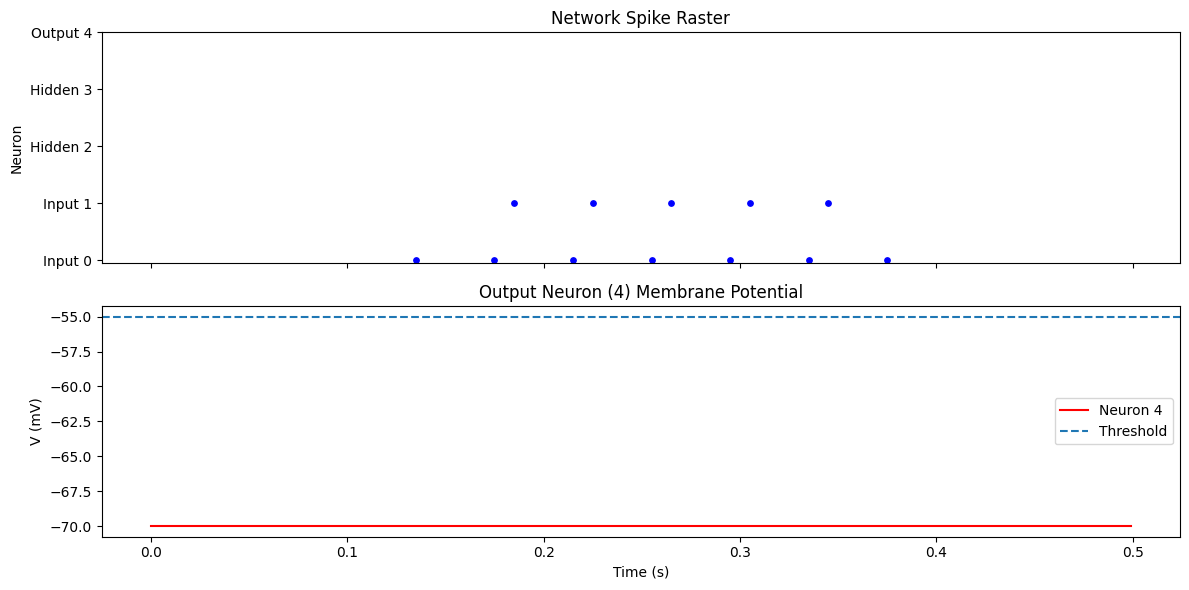

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# TODO 12: Raster plot of all neurons
for n in range(N):
    # Color by neuron type
    if n in [0, 1]:
        color = 'blue'    # input neurons
    elif n in [2, 3]:
        color = 'green'   # hidden neurons
    else:
        color = 'red'     # output neuron

    ax1.scatter(spike_log[n], [n]*len(spike_log[n]), s=15, color=color)

ax1.set_ylabel('Neuron')
ax1.set_title('Network Spike Raster')
ax1.set_yticks(range(N))
ax1.set_yticklabels(['Input 0', 'Input 1', 'Hidden 2', 'Hidden 3', 'Output 4'])

# TODO 13: Plot output neuron membrane potential
ax2.plot(time_net, V_net[:, 4], color='red', label='Neuron 4')
ax2.axhline(V_thresh, linestyle='--', label='Threshold')
ax2.legend()

ax2.set_ylabel('V (mV)')
ax2.set_xlabel('Time (s)')
ax2.set_title('Output Neuron (4) Membrane Potential')

plt.tight_layout()
plt.show()

KNOWLEDGE CHECK

1. Does the output neuron fire at the same rate as the input neurons? Why or why not?

No, it usually fires less often.

Why:

- Input neurons (0 and 1) receive direct external current, so they spike regularly.

- The output neuron (4) only receives spikes indirectly through neurons 2 and 3.

- It needs enough combined synaptic input to reach threshold, so it behaves like a gate or coincidence detector.

2. What role do the synaptic weights play? What would happen if you doubled them? Halved them?

Synaptic weights control how much influence one neuron has on another.

If I doubled the weights:

- Each incoming spike produces a larger voltage push.

- Hidden and output neurons would reach threshold faster.

If I halved the weights:

- Spikes have weaker impact.

- Neurons may take longer to reach threshold, or may not fire at all.

- The output neuron might become silent if input is too weak.

3. In the brain, not all connections are excitatory. What might happen if you made weights[3, 4]
negative (inhibitory)?

Now neuron 3 would suppress neuron 4 instead of exciting it.

Possible effects:

- When neuron 3 spikes, it pulls neuron 4’s voltage downward.

- The output neuron may fire less often, or only when neuron 2 is active without neuron 3.

This mirrors real brain circuits where inhibition sharpens timing, prevents overexcitation, and enables selective responses.

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# --- Common simulation setup ---
dt = 0.001
T = 1.0
time = np.arange(0, T, dt)

V_rest  = -70.0
V_reset = -75.0
V_thresh = -55.0
tau = 0.020
R = 1.0

def simulate_lif(I_input, V_thresh=-55.0, tau=0.020):
    V = np.zeros(len(time))
    V[0] = V_rest
    spikes = []

    for t in range(len(time) - 1):
        dV = (dt / tau) * (-(V[t] - V_rest) + R * I_input[t])
        V[t+1] = V[t] + dV

        if V[t+1] >= V_thresh:
            spikes.append(time[t+1])
            V[t+1] = V_reset

    return V, np.array(spikes)

def make_pulse_current(I_amp=22.0):
    I = np.zeros(len(time))
    I[200:800] = I_amp
    return I

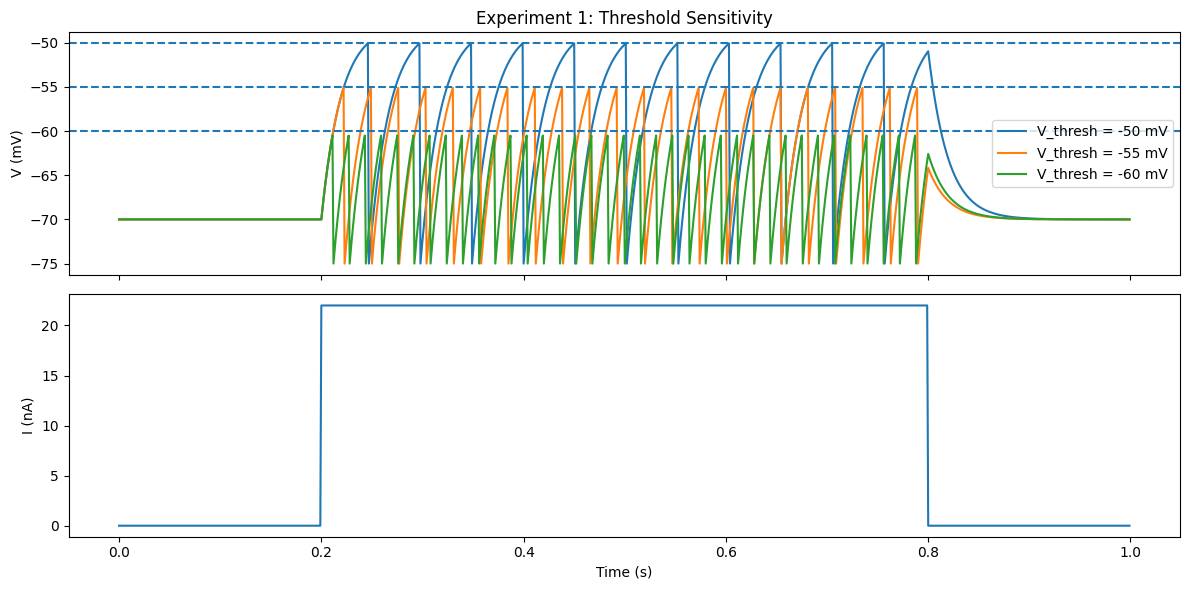

-50 mV: 11 spikes, rate ~ 18.3 Hz (during pulse)
-55 mV: 22 spikes, rate ~ 36.7 Hz (during pulse)
-60 mV: 37 spikes, rate ~ 61.7 Hz (during pulse)


In [20]:
#Experiment 1: Threshold Sensitivity

I_pulse = make_pulse_current(I_amp=22.0)

V1, sp1 = simulate_lif(I_pulse, V_thresh=-50.0, tau=0.020)
V2, sp2 = simulate_lif(I_pulse, V_thresh=-55.0, tau=0.020)
V3, sp3 = simulate_lif(I_pulse, V_thresh=-60.0, tau=0.020)

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax[0].plot(time, V1, label='V_thresh = -50 mV')
ax[0].plot(time, V2, label='V_thresh = -55 mV')
ax[0].plot(time, V3, label='V_thresh = -60 mV')
ax[0].axhline(-50, linestyle='--')
ax[0].axhline(-55, linestyle='--')
ax[0].axhline(-60, linestyle='--')
ax[0].set_ylabel('V (mV)')
ax[0].set_title('Experiment 1: Threshold Sensitivity')
ax[0].legend()

ax[1].plot(time, I_pulse)
ax[1].set_ylabel('I (nA)')
ax[1].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

# Firing rates during the ON window (0.2s to 0.8s => 0.6s)
on_duration = 0.6
print(f"-50 mV: {len(sp1)} spikes, rate ~ {len(sp1)/on_duration:.1f} Hz (during pulse)")
print(f"-55 mV: {len(sp2)} spikes, rate ~ {len(sp2)/on_duration:.1f} Hz (during pulse)")
print(f"-60 mV: {len(sp3)} spikes, rate ~ {len(sp3)/on_duration:.1f} Hz (during pulse)")

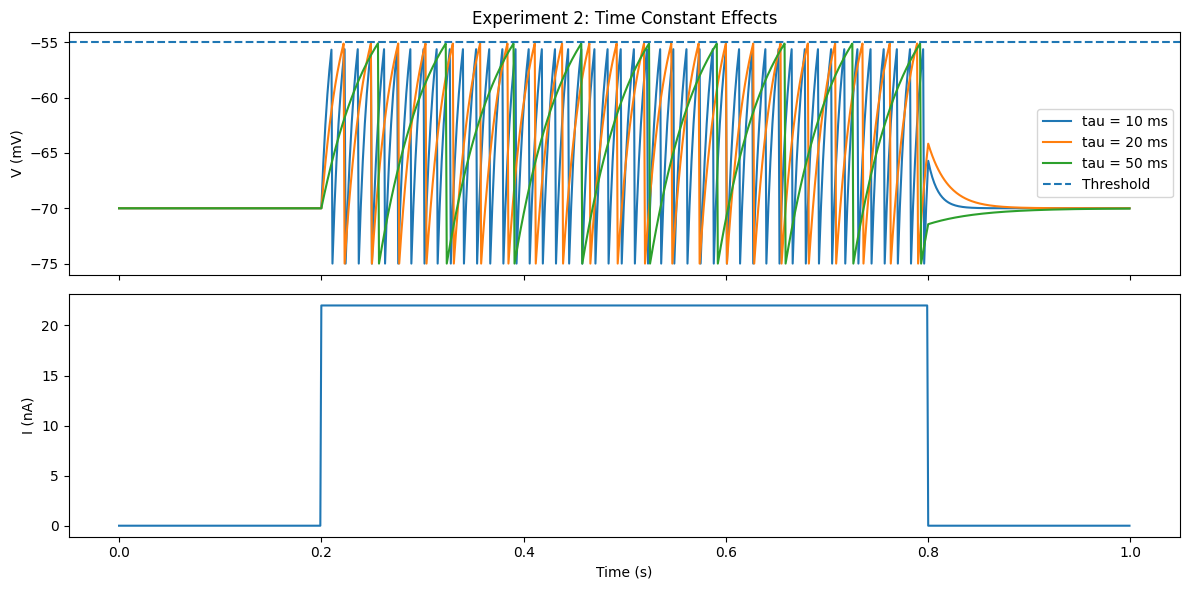

In [21]:
#Experiment 2: Time Constant Effects

V10, sp10 = simulate_lif(I_pulse, V_thresh=-55.0, tau=0.010)
V20, sp20 = simulate_lif(I_pulse, V_thresh=-55.0, tau=0.020)
V50, sp50 = simulate_lif(I_pulse, V_thresh=-55.0, tau=0.050)

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax[0].plot(time, V10, label='tau = 10 ms')
ax[0].plot(time, V20, label='tau = 20 ms')
ax[0].plot(time, V50, label='tau = 50 ms')
ax[0].axhline(V_thresh, linestyle='--', label='Threshold')
ax[0].set_ylabel('V (mV)')
ax[0].set_title('Experiment 2: Time Constant Effects')
ax[0].legend()

ax[1].plot(time, I_pulse)
ax[1].set_ylabel('I (nA)')
ax[1].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

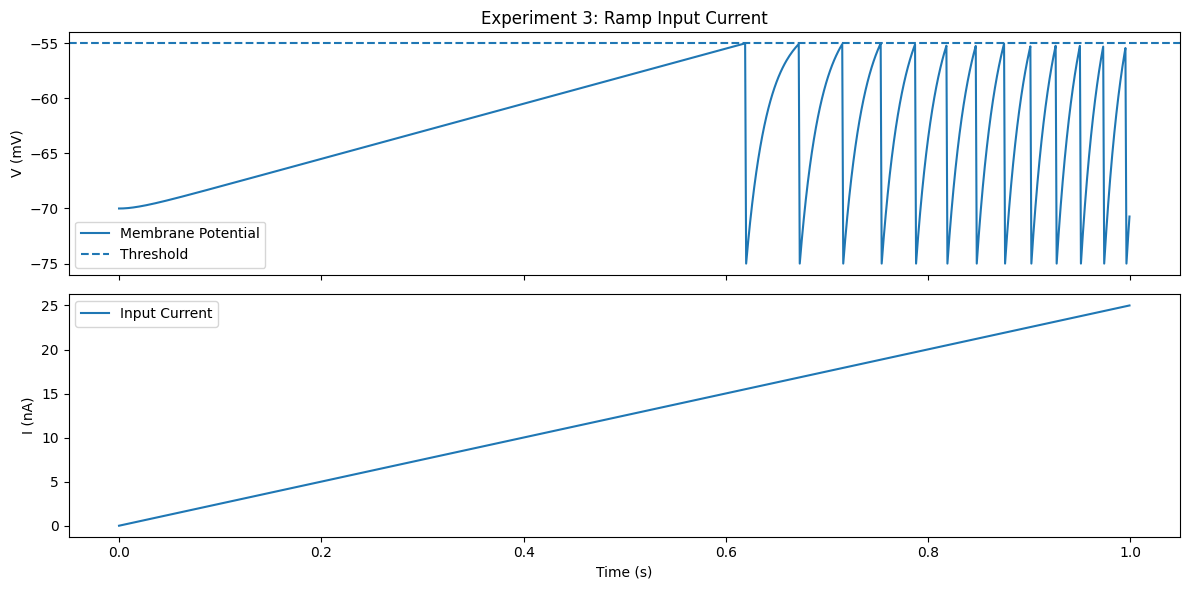

Ramp: 13 total spikes


In [22]:
#Experiment 3: Varying Input Current (ramp)

I_ramp = np.linspace(0, 25, len(time))  # 0 to 25 nA over 1 second
V_ramp, sp_ramp = simulate_lif(I_ramp, V_thresh=-55.0, tau=0.020)

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax[0].plot(time, V_ramp, label='Membrane Potential')
ax[0].axhline(V_thresh, linestyle='--', label='Threshold')
ax[0].set_ylabel('V (mV)')
ax[0].set_title('Experiment 3: Ramp Input Current')
ax[0].legend()

ax[1].plot(time, I_ramp, label='Input Current')
ax[1].set_ylabel('I (nA)')
ax[1].set_xlabel('Time (s)')
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Ramp: {len(sp_ramp)} total spikes")

For Each Experiment, Write:
1. What parameter did you change, and to what values?
2. What did you expect to happen?
3. What actually happened? (Include the plot.)
4. Why does this make sense given the LIF equation?

Experiment 1 — Threshold Sensitivity
Parameter changed:
I varied the spike threshold from −55 mV to −50 mV and −60 mV.

Expectation:
A higher threshold should reduce firing because the neuron needs more depolarization, while a lower threshold should increase firing.

Result:
The −50 mV condition produced fewer spikes, and −60 mV produced more spikes. The membrane potential shape stayed similar, but spike timing shifted.

Explanation (LIF equation):
The threshold does not change the voltage dynamics
τ
d
V
/
d
t
=
−
(
V
−
V
r
e
s
t
)
+
R
I
τdV/dt=−(V−V
rest
​
 )+RI; it only changes when spikes are triggered, so firing rate changes accordingly.

Experiment 2 — Time Constant Effects
Parameter changed:
I changed the membrane time constant τ from 20 ms to 10 ms and 50 ms.

Expectation:
Smaller τ should produce faster voltage changes; larger τ should slow the membrane response.

Result:
With τ = 10 ms, voltage rose quickly and curves were steeper. With τ = 50 ms, voltage changed more slowly and ramps were smoother.

Explanation (LIF equation):
The update term
d
t
/
τ
dt/τ controls how fast voltage evolves, so τ determines the speed of integration and leak.

Experiment 3 — Varying Input Current
Parameter changed:
I replaced constant current with a ramp input
I
(
t
)
=
linspace
(
0
,
25
)
I(t)=linspace(0,25).

Expectation:
Spiking should begin once current is strong enough and then increase over time.

Result:
The neuron was initially silent, then began firing later, with spike intervals shrinking as current increased.

Explanation (LIF equation):
Current enters as
R
I
RI; increasing input raises the depolarizing drive, causing threshold crossings to occur sooner and more frequently.

# Final Reflection


1. How does changing the membrane time constant (τ) affect firing behavior? What biological
property does this represent? (Think about different types of neurons in the brain.)

Smaller τ makes neurons respond quickly and spike faster, while larger τ causes slower, smoother integration. Biologically, τ reflects membrane properties and differs across neuron types depending on how quickly they process inputs.



2. Compare your rate coding and temporal coding results. Which encoding preserved more
information about the original signal? Why might the brain use both strategies in different circuits?

Rate coding preserves overall signal strength but loses precise timing, while temporal coding preserves spike timing and allows faster responses. The brain uses both because some tasks need speed and others need reliable averaging.


3. In your mini SNN, what happened when spikes propagated through layers? How does this relate
to how information flows through real neural circuits?

Spikes moved through layers based on synaptic weights and thresholds, so the output neuron only fired when enough upstream activity arrived. This mirrors real circuits where information is transformed and filtered at each stage.



4. The LIF model is a simplification. What does it capture well about real neurons? What important
biological features does it miss? (Think: dendrites, neurotransmitters, morphology, adaptation.)

The LIF model captures integration, thresholds, and basic spiking dynamics, but misses detailed biology like dendrites, neurotransmitters, ion channels, and adaptation mechanisms.


5. After building these simulations, what is one thing about biological neural computation that
surprised you or changed how you think about artificial intelligence?

A key insight is that complex behavior can emerge from simple timing and threshold rules, showing that biological computation relies heavily on dynamics rather than detailed calculations.